# 16S phyloseq including everything

In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

## consolidate dada2 csv files

### asv table

In [3]:
asv1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_ASV_nochim.csv")

asv2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_ASV_nochim.csv")

asv3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_ASV_nochim.csv")

asv4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_ASV_nochim.csv")

asv5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_ASV_nochim.csv")

In [4]:
#make sure sample names are rownames
to_mat <- function(df) {
  df <- as.data.frame(df)
  rownames(df) <- df[,1]
  df <- df[,-1]
  as.matrix(df)
}
asv1 <- to_mat(asv1)
asv2 <- to_mat(asv2)
asv3 <- to_mat(asv3)
asv4 <- to_mat(asv4)
asv5 <- to_mat(asv5)

In [5]:
#merge using dada2
all_asvs <- Reduce(union, list(
  colnames(asv1),
  colnames(asv2),
  colnames(asv3),
  colnames(asv4),
  colnames(asv5)
))
merge_asv <- function(mat, all_cols) {
  missing <- setdiff(all_cols, colnames(mat))
  if (length(missing) > 0) {
    zero_mat <- matrix(0, nrow = nrow(mat), ncol = length(missing))
    colnames(zero_mat) <- missing
    mat <- cbind(mat, zero_mat)
  }
  mat[, all_cols, drop = FALSE]
}
asv_list <- lapply(list(asv1, asv2, asv3, asv4, asv5),
                   merge_asv,
                   all_cols = all_asvs)

seqtab.all <- do.call(rbind, asv_list)

In [6]:
#check 
sum(seqtab.all) #should be 167M reads
sum(is.na(seqtab.all)) #must be zero
nrow(seqtab.all) #484

[1] 170472134

[1] 0

[1] 484

In [7]:
head(seqtab.all)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

### taxa tables

In [8]:
tax1=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_taxa.csv", header=TRUE, row.names=1)

tax2=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_taxa.csv", header=TRUE, row.names=1)

tax3=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_taxa.csv", header=TRUE, row.names=1)

tax4=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_taxa.csv", header=TRUE, row.names=1)

tax5=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_taxa.csv", header=TRUE, row.names=1)

In [9]:
head(tax1)

,Kingdom,Phylum,Class,Order,Family,Genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodospirillales,Terasakiellaceae,Marivibrio
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,Bacteria,Cyanobacteriota,Cyanobacteriia,Chloroplast,NA,NA


In [10]:
#make sure taxa tables are chr matrices
tax_list <- list(tax1, tax2, tax3, tax4, tax5)
tax_list <- lapply(tax_list, function(x) as.matrix(as.data.frame(x)))

In [11]:
#build full asv

all_asvs <- Reduce(union, lapply(tax_list, rownames)) #all taxa id

In [12]:
#align tax1 to tax2...
align_tax <- function(tax, all_asvs) {
  missing <- setdiff(all_asvs, rownames(tax))
  if (length(missing) > 0) {
    add <- matrix(NA,
                  nrow = length(missing),
                  ncol = ncol(tax))
    rownames(add) <- missing
    colnames(add) <- colnames(tax)
    tax <- rbind(tax, add)
  }
  
  tax[all_asvs, , drop = FALSE]
}

In [13]:
#can also use this cleaner version to align
tax_list <- lapply(tax_list, function(x) {
  x <- as.matrix(x)
  x <- x[order(rownames(x)), ]
  x
})

In [14]:
#merge all runs
tax.all <- Reduce(function(x, y) align_tax(x, all_asvs), ## all sequence ids from taxonomy
                  tax_list)

In [15]:
#check
any(duplicated(rownames(tax.all))) #no dupes

#full coverage
length(setdiff(all_asvs, rownames(tax.all))) #should be 0

#any missing
colSums(is.na(tax.all))

[1] FALSE

[1] 0

Kingdom  Phylum   Class   Order  Family   Genus 
 161533  166390  171454  185809  200283  243624

### meta table

In [16]:
meta <- read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

In [17]:
head(seqtab.all)
head(tax.all)
head(meta)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

,Kingdom,Phylum,Class,Order,Family,Genus
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodospirillales,Terasakiellaceae,Marivibrio
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,Bacteria,Cyanobacteriota,Cyanobacteriia,Chloroplast,NA,NA


,X,Tubelabel_species,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,Extraction_physical_location,immune_y.n,Condition,Date_16S,Date_ITS2,Seq_run,Transect
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,104,052022_BEL_CBC_T1_2_SSID,12_2_2024,7.73,,,52022,1_3,5/21/22,SSID,Diseased_Tissue,UML_NARWHAL_R1_B3,"UML_NARWHAL_R2_B14, UML_NARWHAL_R2_B33",y,Diseased,1_22_2025,6_26_2025,1,CBC30N
2,232,092023_BEL_CBC_T1_175_PAST,1_15_2025,2.3,,,92023,1_13,9/25/23,PAST,Healthy,UML_NARWHAL_R1_B10,UML_NARWHAL_R2_B12,y,Healthy,1_22_2025,6_26_2025,1,CBC30N
3,59,022024_BEL_CBC_T3_851_PSTR,11_26_2024,64.2,,,22024,3_70,2/24/24,PSTR,Healthy,UML_NARWHAL_R5_B23,UML_NARWHAL_R2_B13,y,Healthy,1_23_2025,6_26_2025,1,Lagoon
4,225,082024_BEL_CBC_T4_1609_OFAV,1_15_2025,61.2,,,82024,4_78,8/22/24,OFAV,Healthy,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,1_23_2025,6_26_2025,1,Curlew
5,360,122023_BEL_CBC_T3_526_SSID,11_19_2024,16.4,,,122023,3_5,12/16/23,SSID,Healthy,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,Healthy,1_23_2025,6_26_2025,1,Lagoon
6,300,112023_BEL_CBC_T4_399_MCAV,11_15_2024,13.9,,,112023,4_76,11/13/23,MCAV,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B12,y,CLP,1_23_2025,6_26_2025,1,Curlew


In [18]:
nrow(seqtab.all)
nrow(meta)

[1] 484

[1] 475

### clean sample data
- make a date_formatted column to put dates in chronological order
- make tubelabel_spec rownames


In [19]:
#chnage month year date format
#changing format of Month_year to be Jan 2024 using collection date
meta$CollectionDate <- as.factor(meta$CollectionDate)
# Convert to Date format 
meta$DateFormatted <- as.Date(paste0(meta$CollectionDate), format = "%m/%d/%y")
# now will have a new column that has Month Year instead of date_sampled
meta$Month_year <- format(meta$DateFormatted, "%b %Y")
meta$Month_year <- factor(meta$Month_year, levels = unique(meta$Month_year))
class(meta)

[1] "data.frame"

In [20]:
# Find duplicates
meta$Tubelabel_species[duplicated(meta$Tubelabel_species)]
#remove blank rows
meta <- meta[meta$Tubelabel_species != "" & !is.na(meta$Tubelabel_species), ]

character(0)

In [21]:
rownames(meta) <- meta$Tubelabel_species 

In [22]:
#cleaning up meta to only be of interest
meta_clean<- meta[, c( "Health_status", "colony", "Date_16S", "Condition", "Species", "Month_year", "Seq_run", "Transect", "DateFormatted")]

#MonthYear in chronological order
head(meta_clean)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


In [23]:
nrow(seqtab.all)
nrow(meta_clean)

[1] 484

[1] 475

In [24]:
### match asv and meta rownames
#### make sure they have _ not -

In [25]:
row.names(seqtab.all) <- gsub('-', '_', row.names(seqtab.all))

In [26]:
head(seqtab.all)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

## it is a red flag to have otus that dont show up in any samples
- https://github.com/benjjneb/dada2/issues/1958
- 2206 otus that dont show up in any samples

### potentially redo dada2 with all 16S seqs together

In [27]:
class(seqtab.all)
#are there any columns in seqtab.all that only have zero
any(colSums(seqtab.all != 0) == 0)
# if TRUE there are ASV columns that contain only zeros across all samples

[1] "matrix" "array"

[1] FALSE

In [28]:
nrow(seqtab.all)
nrow(meta_clean)

[1] 484

[1] 475

In [29]:
#how many are true how many are false
table(colSums(seqtab.all != 0) == 0)


 FALSE 
268938 

In [30]:
ncol(seqtab.all)

[1] 268938

In [31]:
nrow(seqtab.all)
nrow(meta_clean)

[1] 484

[1] 475

## prep for phyloseq

In [32]:
nrow(meta_clean)
nrow(seqtab.all)

[1] 475

[1] 484

## which 5 samples are in seq.tab all that do not exist in meta_clean?
- removing 9 negatives (and undetermined) seqs because they don't exist in meta_pcr
- removing 2 ORBI samples bc names were different in meta_pcr
- remove 3 samples that exist in both meta and seqtab for mysterious reasons
    - 1439_OFAV
    - 528_PAST
    - 479_PAST

In [33]:
# Convert matrix to data frame and move row names to a new column
seqtab_df <- as.data.frame(seqtab.all) 
head(seqtab_df)
seqtab_df$Tubelabel_species <- rownames(seqtab_df)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

In [34]:
# what does R think is in the 1439 row
## hidden space!
# Search your metadata for that specific sample row

# 1. Grab the exact string from seqtab_df
str_seq <- seqtab_df$Tubelabel_species[grep("1439", seqtab_df$Tubelabel_species)][1]

# 2. Grab the exact string from meta
str_meta <- meta$Tubelabel_species[grep("1439", meta$Tubelabel_species)][1]

# 3. Print their raw bytes to find the hidden difference
charToRaw(str_seq)
charToRaw(str_meta)

 [1] 58 30 36 32 30 32 34 5f 42 45 4c 5f 43 42 43 5f 54 33 5f 31 34 33 39 5f 4f
[26] 46 41 56

 [1] 30 36 32 30 32 34 5f 42 45 4c 5f 43 42 43 5f 54 33 5f 31 34 33 39 5f 4f 46
[26] 41 56 20

In [35]:
# remove potential white spaces
seqtab_df <- seqtab_df %>% mutate(Tubelabel_species = str_trim(Tubelabel_species))
meta <- meta %>% mutate(Tubelabel_species = str_trim(Tubelabel_species))

In [36]:
## clean sample names
seqtab_df$Tubelabel_species <- sub("^X", "", seqtab_df$Tubelabel_species)
head(seqtab_df)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TCTTATACACATCTCCGAGCCCACGAGACCGAGACTAATCTGGGGGGGGGGGGTGGGGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

In [37]:
# Keep rows in df1_clean whose 'id' does not appear in df2_clean
missing_samples <- anti_join(seqtab_df, meta, by = "Tubelabel_species")
missing_samples

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TCTTATACACATCTCCGAGCCCACGAGACCGAGACTAATCTGGGGGGGGGGGGTGGGGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

## back to seqtab.all and meta rownames

In [47]:
# Remove leading and trailing whitespaces
rownames(seqtab.all) <- trimws(rownames(seqtab.all))

# Remove leading and trailing whitespaces/tabs/newlines
rownames(meta_clean) <- trimws(rownames(meta_clean))

In [49]:
# rownames for asv and meta match
#make sure rownames are in same order
common_samples <- intersect(rownames(meta_clean), rownames(seqtab.all))

# Reorder both objects to match the same order
meta_common <- meta_clean[common_samples, , drop = FALSE]
seqtab.all_common <- seqtab.all[common_samples, , drop = FALSE]

In [50]:
nrow(meta_common)
nrow(seqtab.all_common)

[1] 475

[1] 475

In [51]:
## colnames for taxa and asv 

# Reorder taxa to match asv_all
#Get common ASVs
common_asvs <- intersect(colnames(seqtab.all), rownames(tax.all))

# Subset both
seqtab.all <- seqtab.all[, common_asvs]
tax.all <- tax.all[common_asvs, ]

sum(is.na(match(colnames(seqtab.all), rownames(tax.all))))
identical(colnames(seqtab.all), rownames(tax.all))  # Should be TRUE

#check if asv_clean is numeric
all(sapply(as.data.table(seqtab.all), is.numeric))


[1] 0

[1] TRUE

[1] TRUE

In [52]:
## final checks

#check if row names and column names match
identical(colnames(seqtab.all), rownames(tax.all))  # MUST be TRUE
identical(rownames(seqtab.all), rownames(meta_clean))  # MUST be TRUE

[1] TRUE

[1] FALSE

In [53]:
class(seqtab.all)
class(meta_clean)
class(tax.all)

[1] "matrix" "array"

[1] "data.frame"

[1] "matrix" "array"

In [54]:
#how many rows are in seqtab.all and in meta_clean?

## phyloseq

In [55]:
# Convert asv_all to otu_table (specify taxa_are_rows = TRUE/FALSE depending on your data)
otu <- otu_table(seqtab.all, taxa_are_rows = FALSE)  # or TRUE if taxa in rows

# Sample metadata as sample_data
meta <- sample_data(meta_clean)

tax.all=as.matrix(tax.all)

taxa=tax_table(tax.all)

In [56]:
# Construct phyloseq object
ps <- phyloseq(otu, meta, taxa)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [57]:
saveRDS(ps, file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")

## check counts of ps object
-matches original dada2 counts!

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


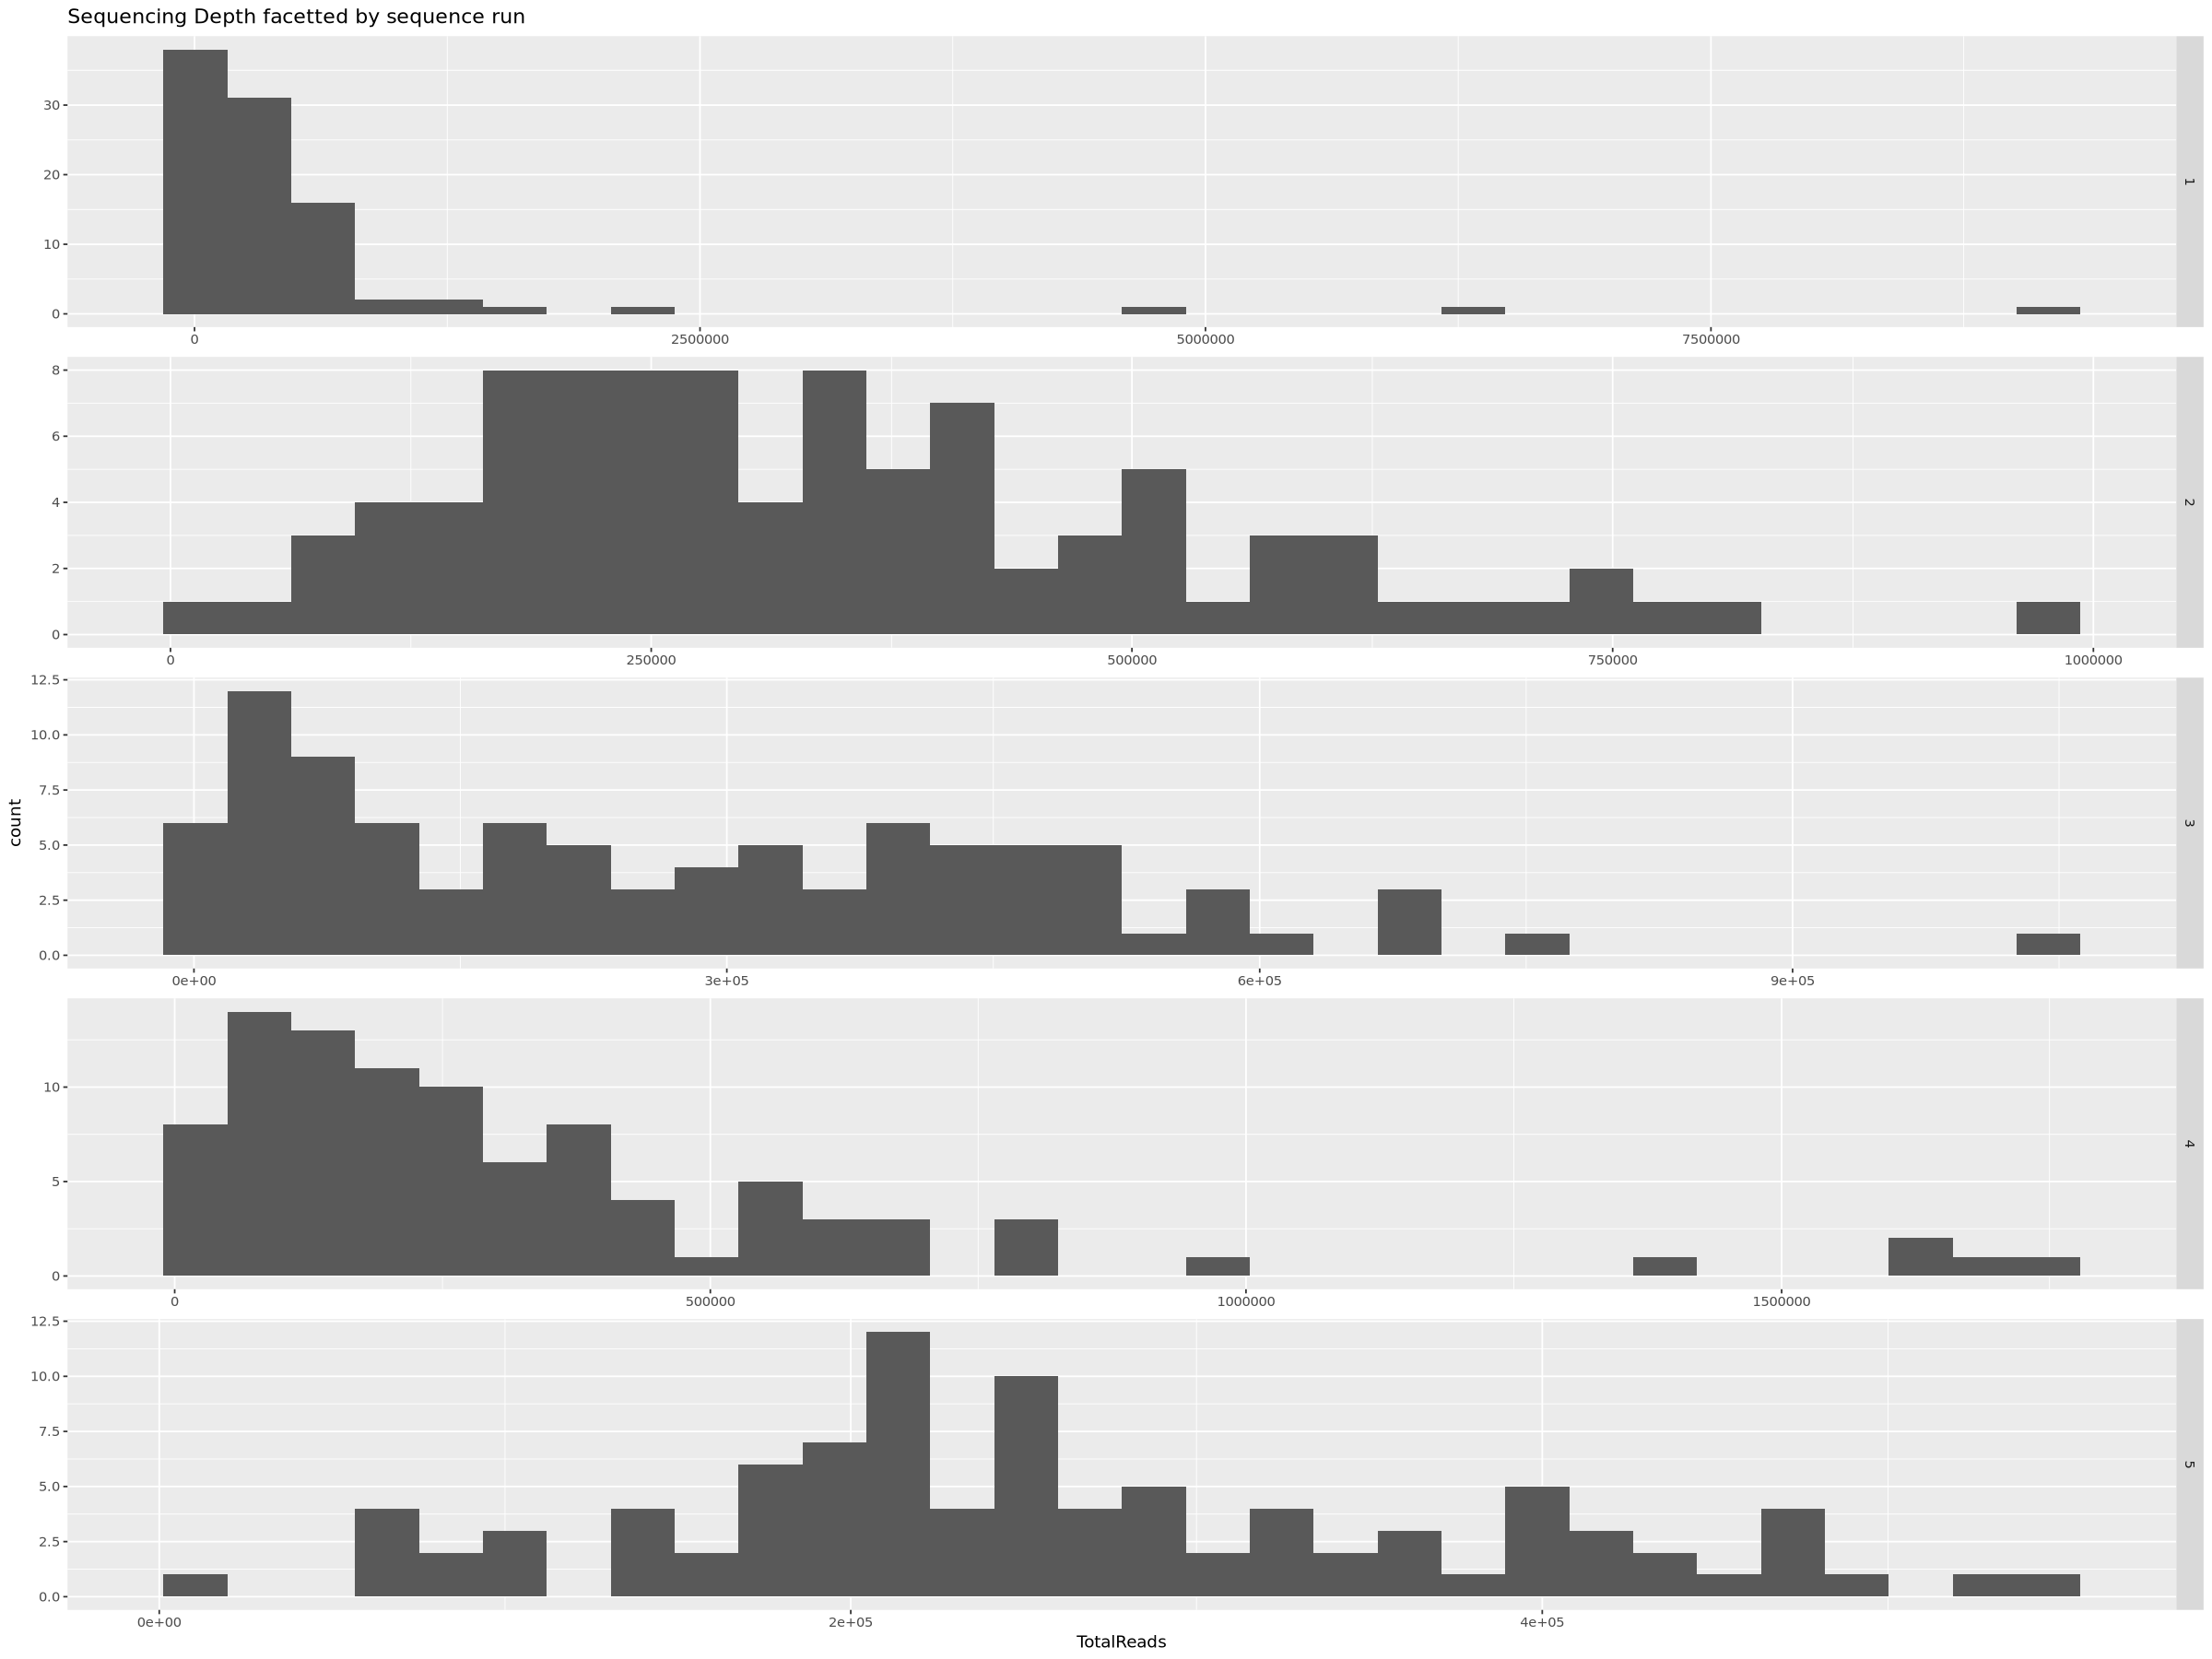

In [35]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales = "free")  # Set desired font size

In [36]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

                        SampleID TotalReads
                          <char>      <num>
  1:  012024_BEL_CBC_T1_561_OANN        765
  2:  042024_BEL_CBC_T3_960_OFAV       3853
  3:  122022_BEL_CBC_T3_142_MCAV       4868
  4:   122022_BEL_CBC_T2_85_MCAV      10429
  5:  042024_BEL_CBC_T3_956_MCAV      11488
 ---                                       
466:  012024_BEL_CBC_T3_625_SSID    1749091
467: 042024_BEL_CBC_T2_1018_PAST    2096344
468: 082024_BEL_CBC_T3_1562_OFAV    4651047
469: 062024_BEL_CBC_T2_1375_SSID    6257366
470:  092023_BEL_CBC_T2_184_MCAV    9169329


In [37]:
median(readcount$TotalReads)

sum(sample_sums(ps))

[1] 260022

[1] 166228141

In [38]:
readcount[, min(TotalReads)]
mean(readcount$TotalReads)

[1] 765

[1] 353676.9

In [39]:
## investigate physeq object

# Create table, number of features for each phyla
table(tax_table(ps)[, "Phylum"], exclude = NULL)


                     10bav-F6              Abditibacteriota 
                            2                             1 
                 Acetothermia               Acidobacteriota 
                           21                          2880 
               Actinomycetota               Aenigmarchaeota 
                         1340                            44 
                Altiarchaeota                         AncK6 
                            5                            26 
               Armatimonadota               Asgardarchaeota 
                           13                            44 
                    Bacillota                  Bacteroidota 
                         1162                          9366 
                   Balneolota              Bdellovibrionota 
                           89                          3518 
                Caldisericota                 Calditrichota 
                            1                           191 
             Campylobac

removing uncharacterized taxa

In [40]:
ps <- subset_taxa(ps, !is.na(Phylum) & !Phylum %in% c("", "uncharacterized"))

find number of samples in which a taxon appears at least once

In [41]:
# Compute prevalence of each feature, store as data.frame
prevdf = apply(X = otu_table(ps),
               MARGIN = ifelse(taxa_are_rows(ps), yes = 1, no = 2),
               FUN = function(x){sum(x > 0)})
# Add taxonomy and total read counts to this data.frame
prevdf = data.frame(Prevalence = prevdf,
                    TotalAbundance = taxa_sums(ps),
                    tax_table(ps))

### total and average prevalences in each phylum
- The first column generated by cbind(), which contains the mean (average) prevalence for each phylum ($mean(df1\$Prevalence)$)
- The second column generated by cbind(), which contains the sum (total) prevalence for each phylum ($sum(df1\$Prevalence)$).

In [42]:
plyr::ddply(prevdf, "Phylum", function(df1){
  cbind(Average_Prevalence = mean(df1$Prevalence), 
        Total_Prevalence = sum(df1$Prevalence))
})

Phylum,Average_Prevalence,Total_Prevalence
<chr>,<dbl>,<dbl>
10bav-F6,1.500000,3
Abditibacteriota,1.000000,1
Acetothermia,4.285714,90
Acidobacteriota,6.434375,18531
Actinomycetota,12.563433,16835
Aenigmarchaeota,2.863636,126
Altiarchaeota,1.800000,9
AncK6,8.076923,210
Armatimonadota,2.000000,26


visualize prevalence across phyla 

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


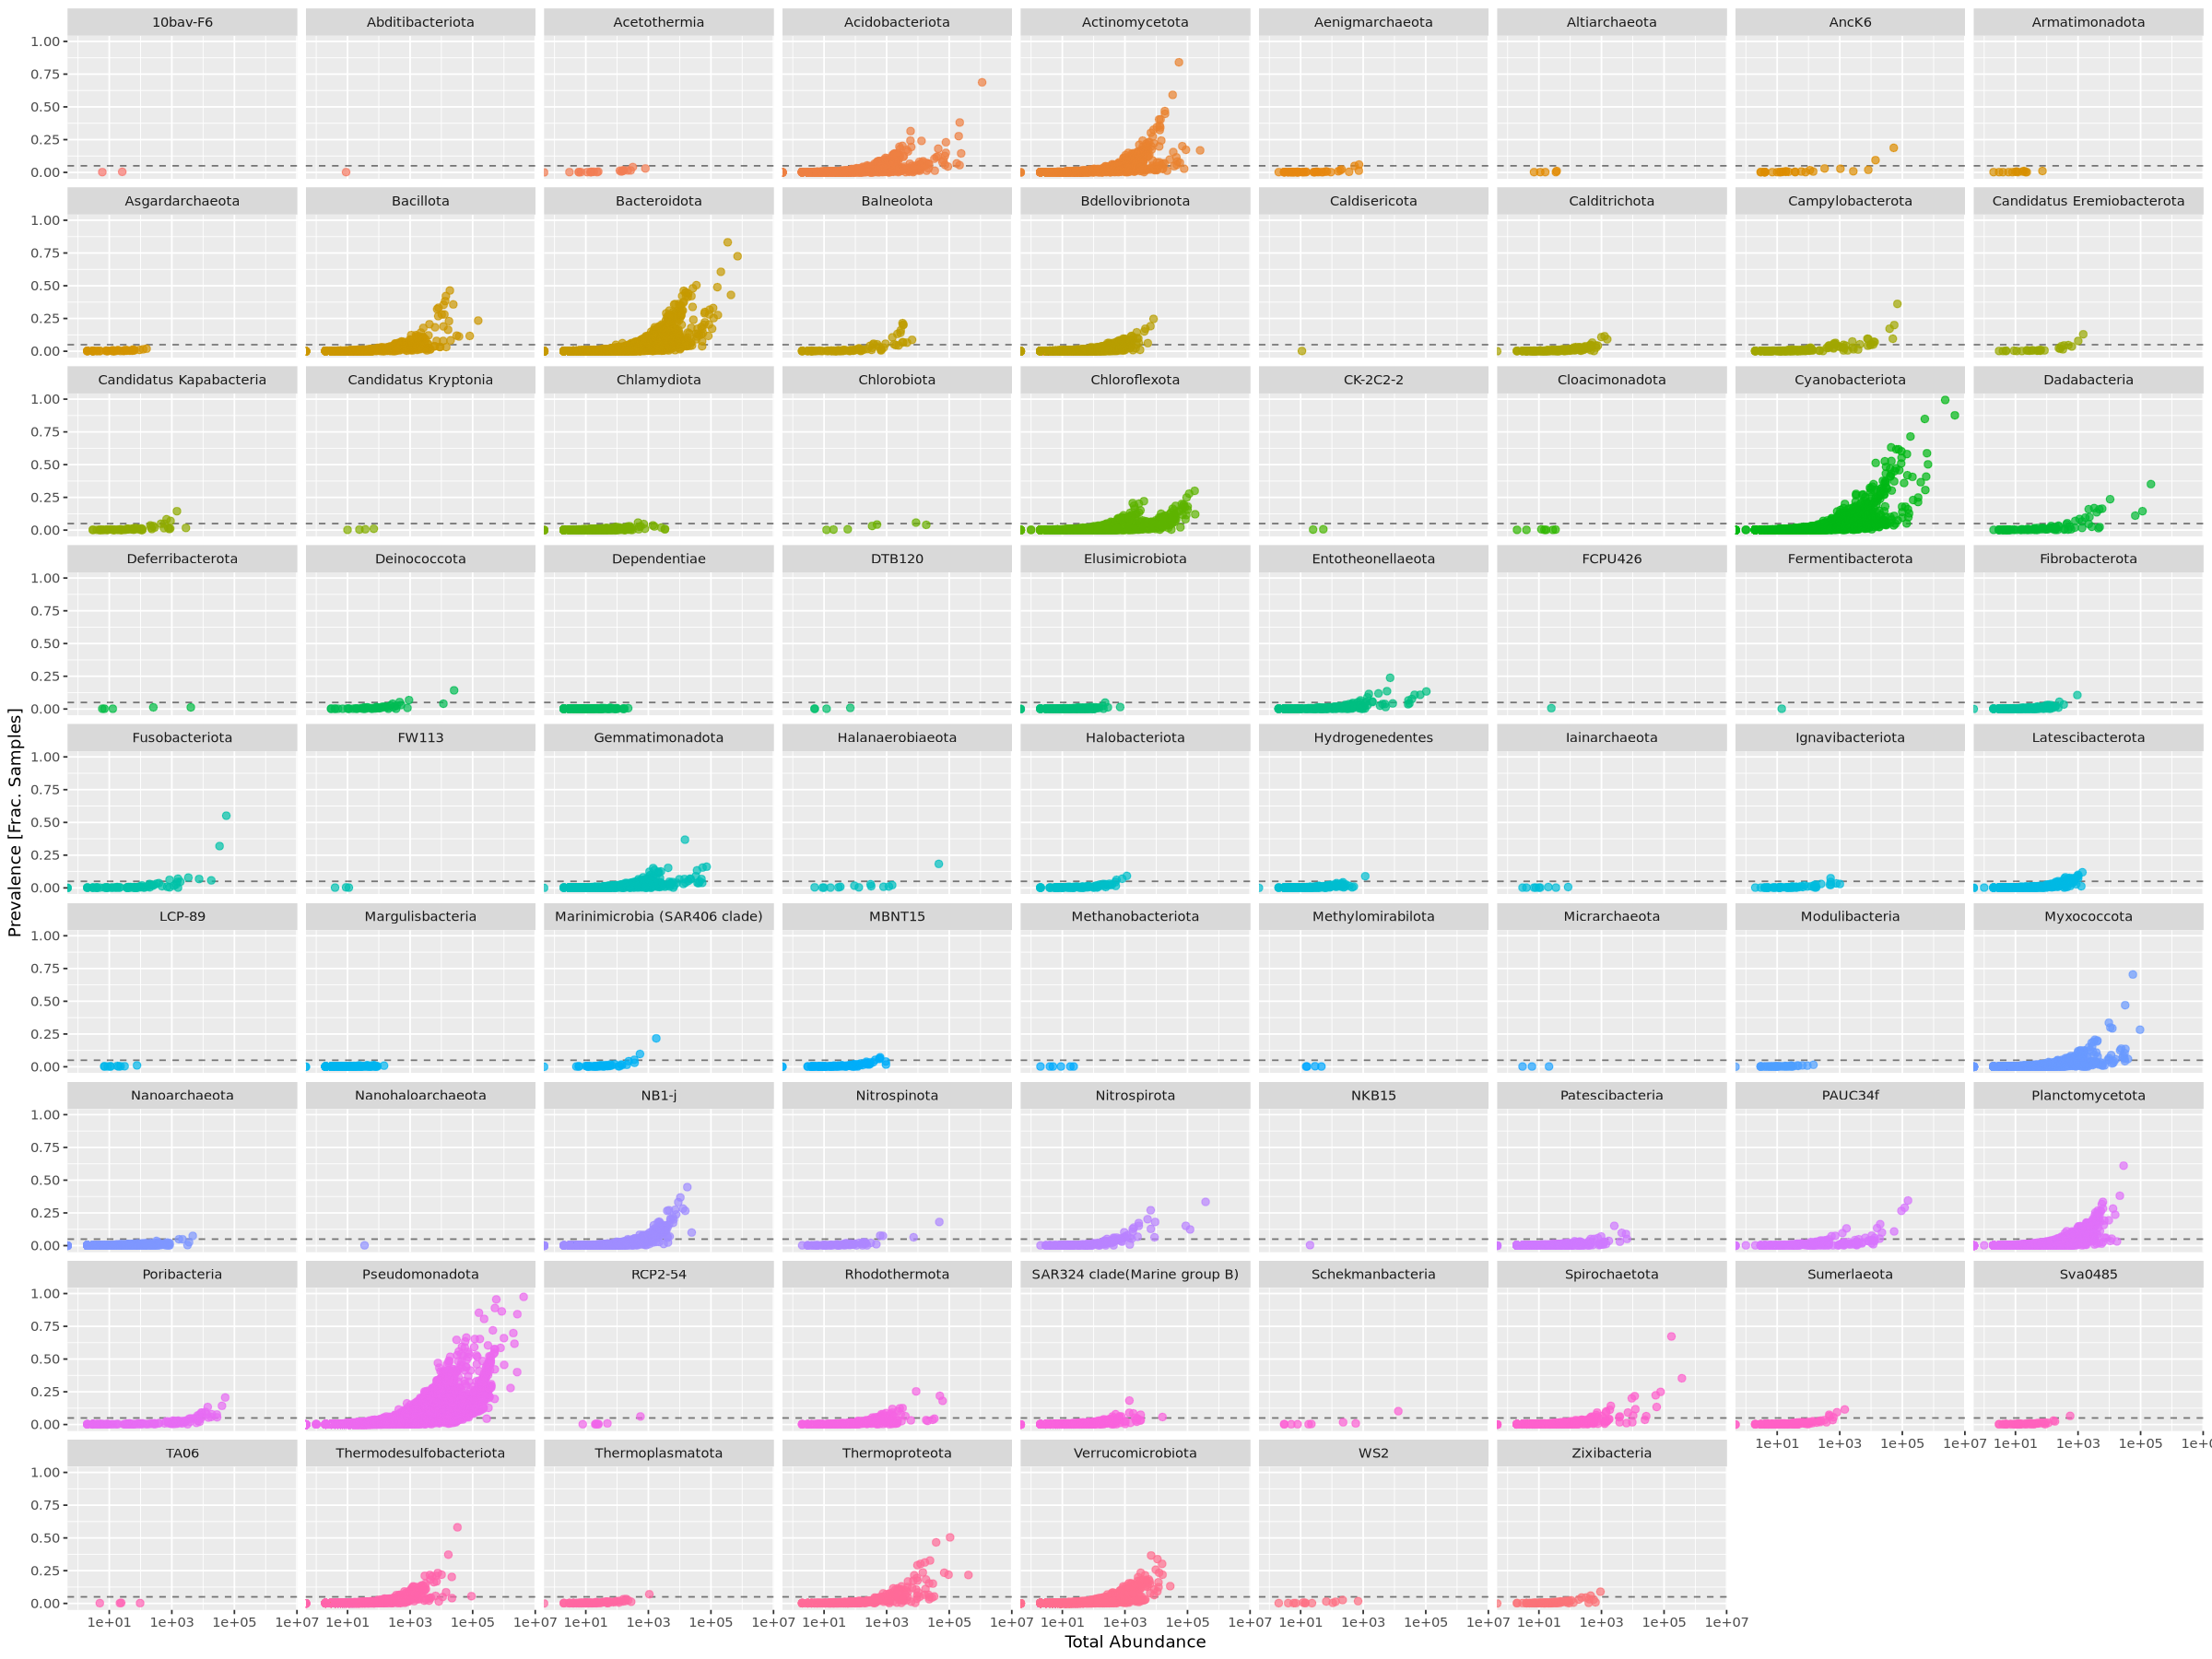

In [43]:
# Subset to the remaining phyla
prevdf1 = subset(prevdf, Phylum %in% get_taxa_unique(ps, "Phylum"))
ggplot(prevdf1, aes(TotalAbundance, Prevalence / nsamples(ps),color=Phylum)) +
  # Include a guess for parameter
  geom_hline(yintercept = 0.05, alpha = 0.5, linetype = 2) +  geom_point(size = 2, alpha = 0.7) +
  scale_x_log10() +  xlab("Total Abundance") + ylab("Prevalence [Frac. Samples]") +
  facet_wrap(~Phylum) + theme(legend.position="none")

## the figure above shows us that phyla with highest prevalence across all samples are:
- Cyanobacteria
- Psuedomonadota
- Actinomyceota
- Bacteroidota

## clean up physeq object

In [44]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [45]:
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
ps_bac

#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo

#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 100273 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 100273 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [46]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46460 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46460 taxa by 6 taxonomic ranks ]

## investigate cleaned physeq object

In [47]:
# Create table, number of features for each phyla
table(tax_table(ps_prune)[, "Phylum"], exclude = NULL)


            Abditibacteriota                 Acetothermia 
                           1                            4 
             Acidobacteriota               Actinomycetota 
                        1145                          894 
              Armatimonadota                    Bacillota 
                          10                          905 
                Bacteroidota                   Balneolota 
                        7102                           89 
            Bdellovibrionota                Caldisericota 
                        3159                            1 
               Calditrichota             Campylobacterota 
                         190                          147 
        Candidatus Kryptonia                  Chlamydiota 
                           4                          519 
                 Chlorobiota                Chloroflexota 
                           4                          828 
              Cloacimonadota              Cyanobacterio

In [48]:
# Compute prevalence of each feature, store as data.frame
prev_prune = apply(X = otu_table(ps_prune),
               MARGIN = ifelse(taxa_are_rows(ps_prune), yes = 1, no = 2),
               FUN = function(x){sum(x > 0)})
# Add taxonomy and total read counts to this data.frame
prev_prune = data.frame(Prevalence = prev_prune,
                    TotalAbundance = taxa_sums(ps_prune),
                    tax_table(ps_prune))

In [49]:
# total and average phylum prev
plyr::ddply(prev_prune, "Phylum", function(df2){
  cbind(Average_Prevalence = mean(df2$Prevalence), 
        Total_Prevalence = sum(df2$Prevalence))
})

Phylum,Average_Prevalence,Total_Prevalence
<chr>,<dbl>,<dbl>
Abditibacteriota,1.000000,1
Acetothermia,3.000000,12
Acidobacteriota,6.487336,7428
Actinomycetota,13.295302,11886
Armatimonadota,1.700000,17
Bacillota,8.508287,7700
Bacteroidota,9.183188,65219
Balneolota,12.179775,1084
Bdellovibrionota,3.647990,11524


visualize the phyla 

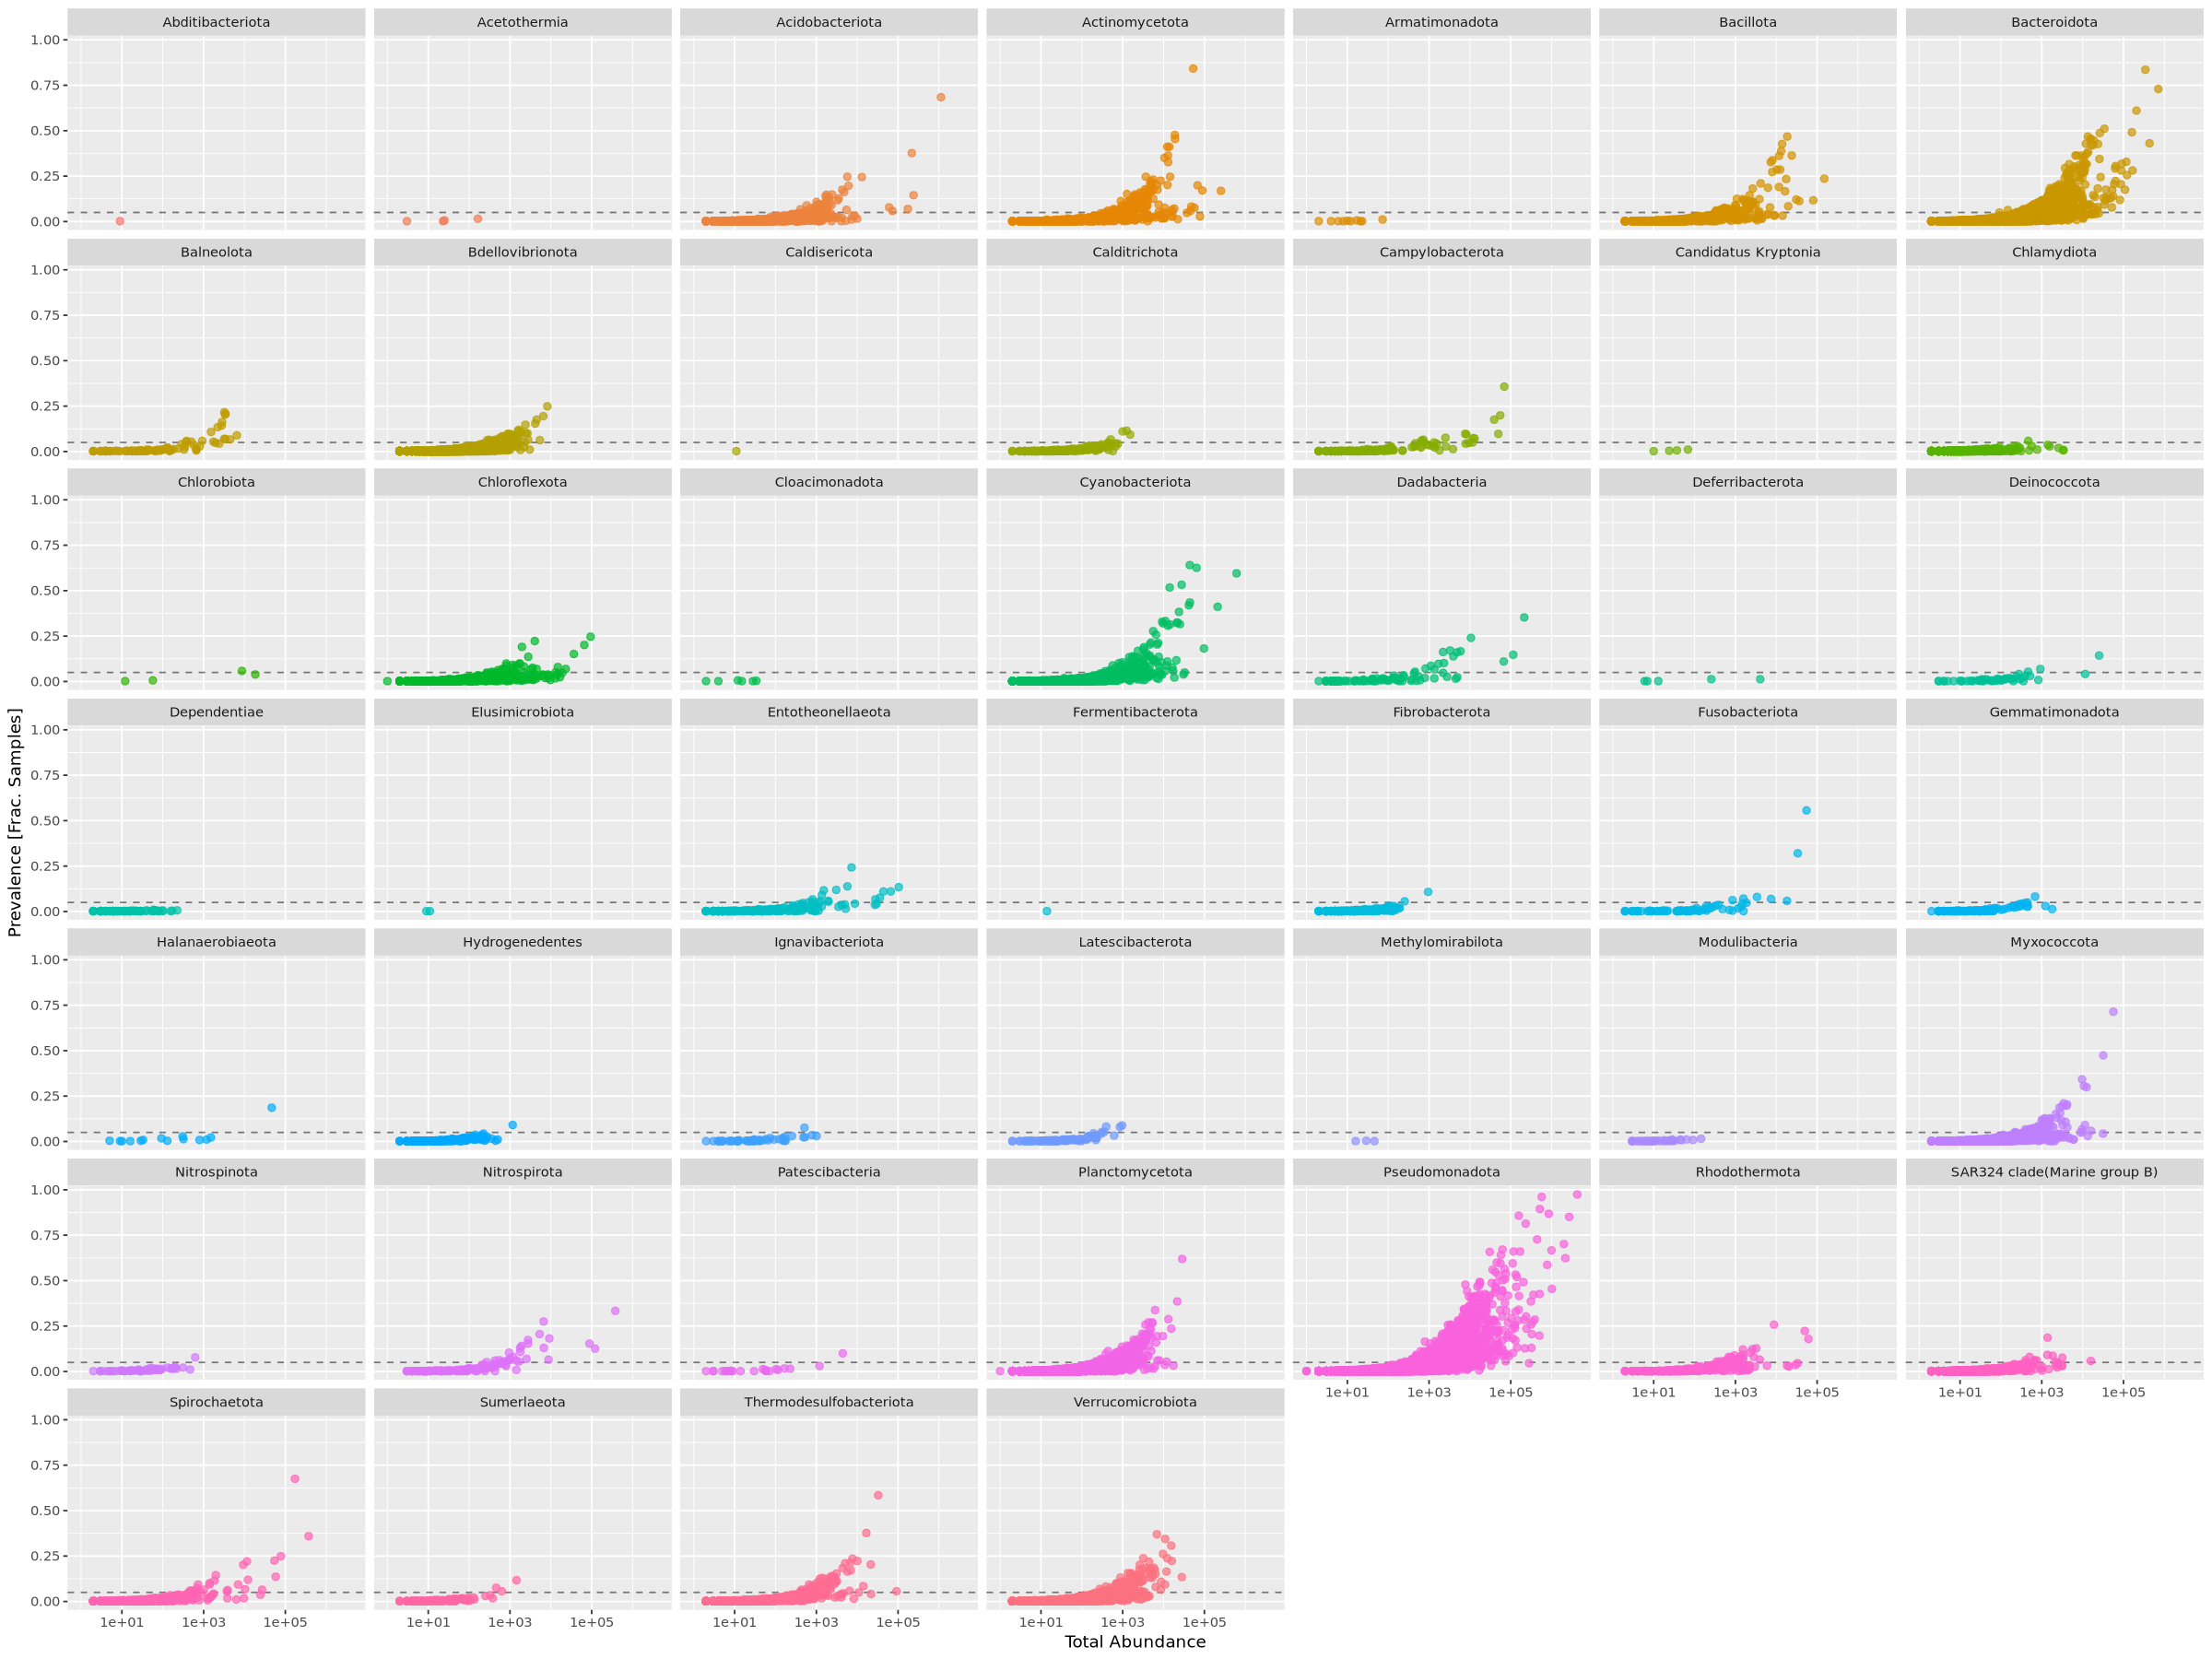

In [50]:
# Subset to the remaining phyla
prevdf2 = subset(prev_prune, Phylum %in% get_taxa_unique(ps_prune, "Phylum"))
ggplot(prev_prune, aes(TotalAbundance, Prevalence / nsamples(ps_prune),color=Phylum)) +
  # Include a guess for parameter
  geom_hline(yintercept = 0.05, alpha = 0.5, linetype = 2) +  geom_point(size = 2, alpha = 0.7) +
  scale_x_log10() +  xlab("Total Abundance") + ylab("Prevalence [Frac. Samples]") +
  facet_wrap(~Phylum) + theme(legend.position="none")

selecting filtering parameters, like the minimum prevalence criteria we will used to filter the data above.

In [51]:
# Define prevalence threshold as 5% of total samples
# tell R to Throw away any ASV/OTU that doesn't show up in at least 5% of my total samples
prevalenceThreshold = 0.05 * nsamples(ps_prune)
prevalenceThreshold

[1] 23.1

In [52]:
# Execute prevalence filter, using `prune_taxa()` function
keepTaxa = rownames(prevdf2)[(prevdf2$Prevalence >= prevalenceThreshold)]
ps_5percent = prune_taxa(keepTaxa, ps_prune)

In [53]:
# How many families would be present before filtering?
length(get_taxa_unique(ps_prune, taxonomic.rank = "Family"))
# How many families would be present after filtering?
length(get_taxa_unique(ps_5percent, taxonomic.rank = "Family"))

[1] 469

[1] 236

In [54]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))
                                  ps_norm

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46460 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46460 taxa by 6 taxonomic ranks ]

In [55]:
ps_norm_5 = transform_sample_counts(ps_5percent, function(x) 1E6 * x / sum(x))
                                  ps_norm_5

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 3600 taxa and 462 samples ]
sample_data() Sample Data:       [ 462 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 3600 taxa by 6 taxonomic ranks ]

# what does having a prevalence threshold: using phyla that appear in >5% of cleaned samples (after removing mito and chloroplast) do to taxa plots
- when using top 50 family taxa it doesnt change much
- when using top 300

## top 50 taxa
- when using top 50 famiily the prevalence threshold doesnt change the outcome of the data visualization 

### taxa all

In [56]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "Family"]))

#reduce that to top 50
ps_fam=tax_glom(ps_norm, taxrank= "Family")

#isolating top 50 family taxa
top50<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:50] 
ps_fam_50 <- prune_taxa(top50, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam_50)[, "Family"]))

[1] 469

[1] 50

In [57]:
#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(ps_fam_50)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


<Guides[1] ggproto object>

colour : <GuideLegend>

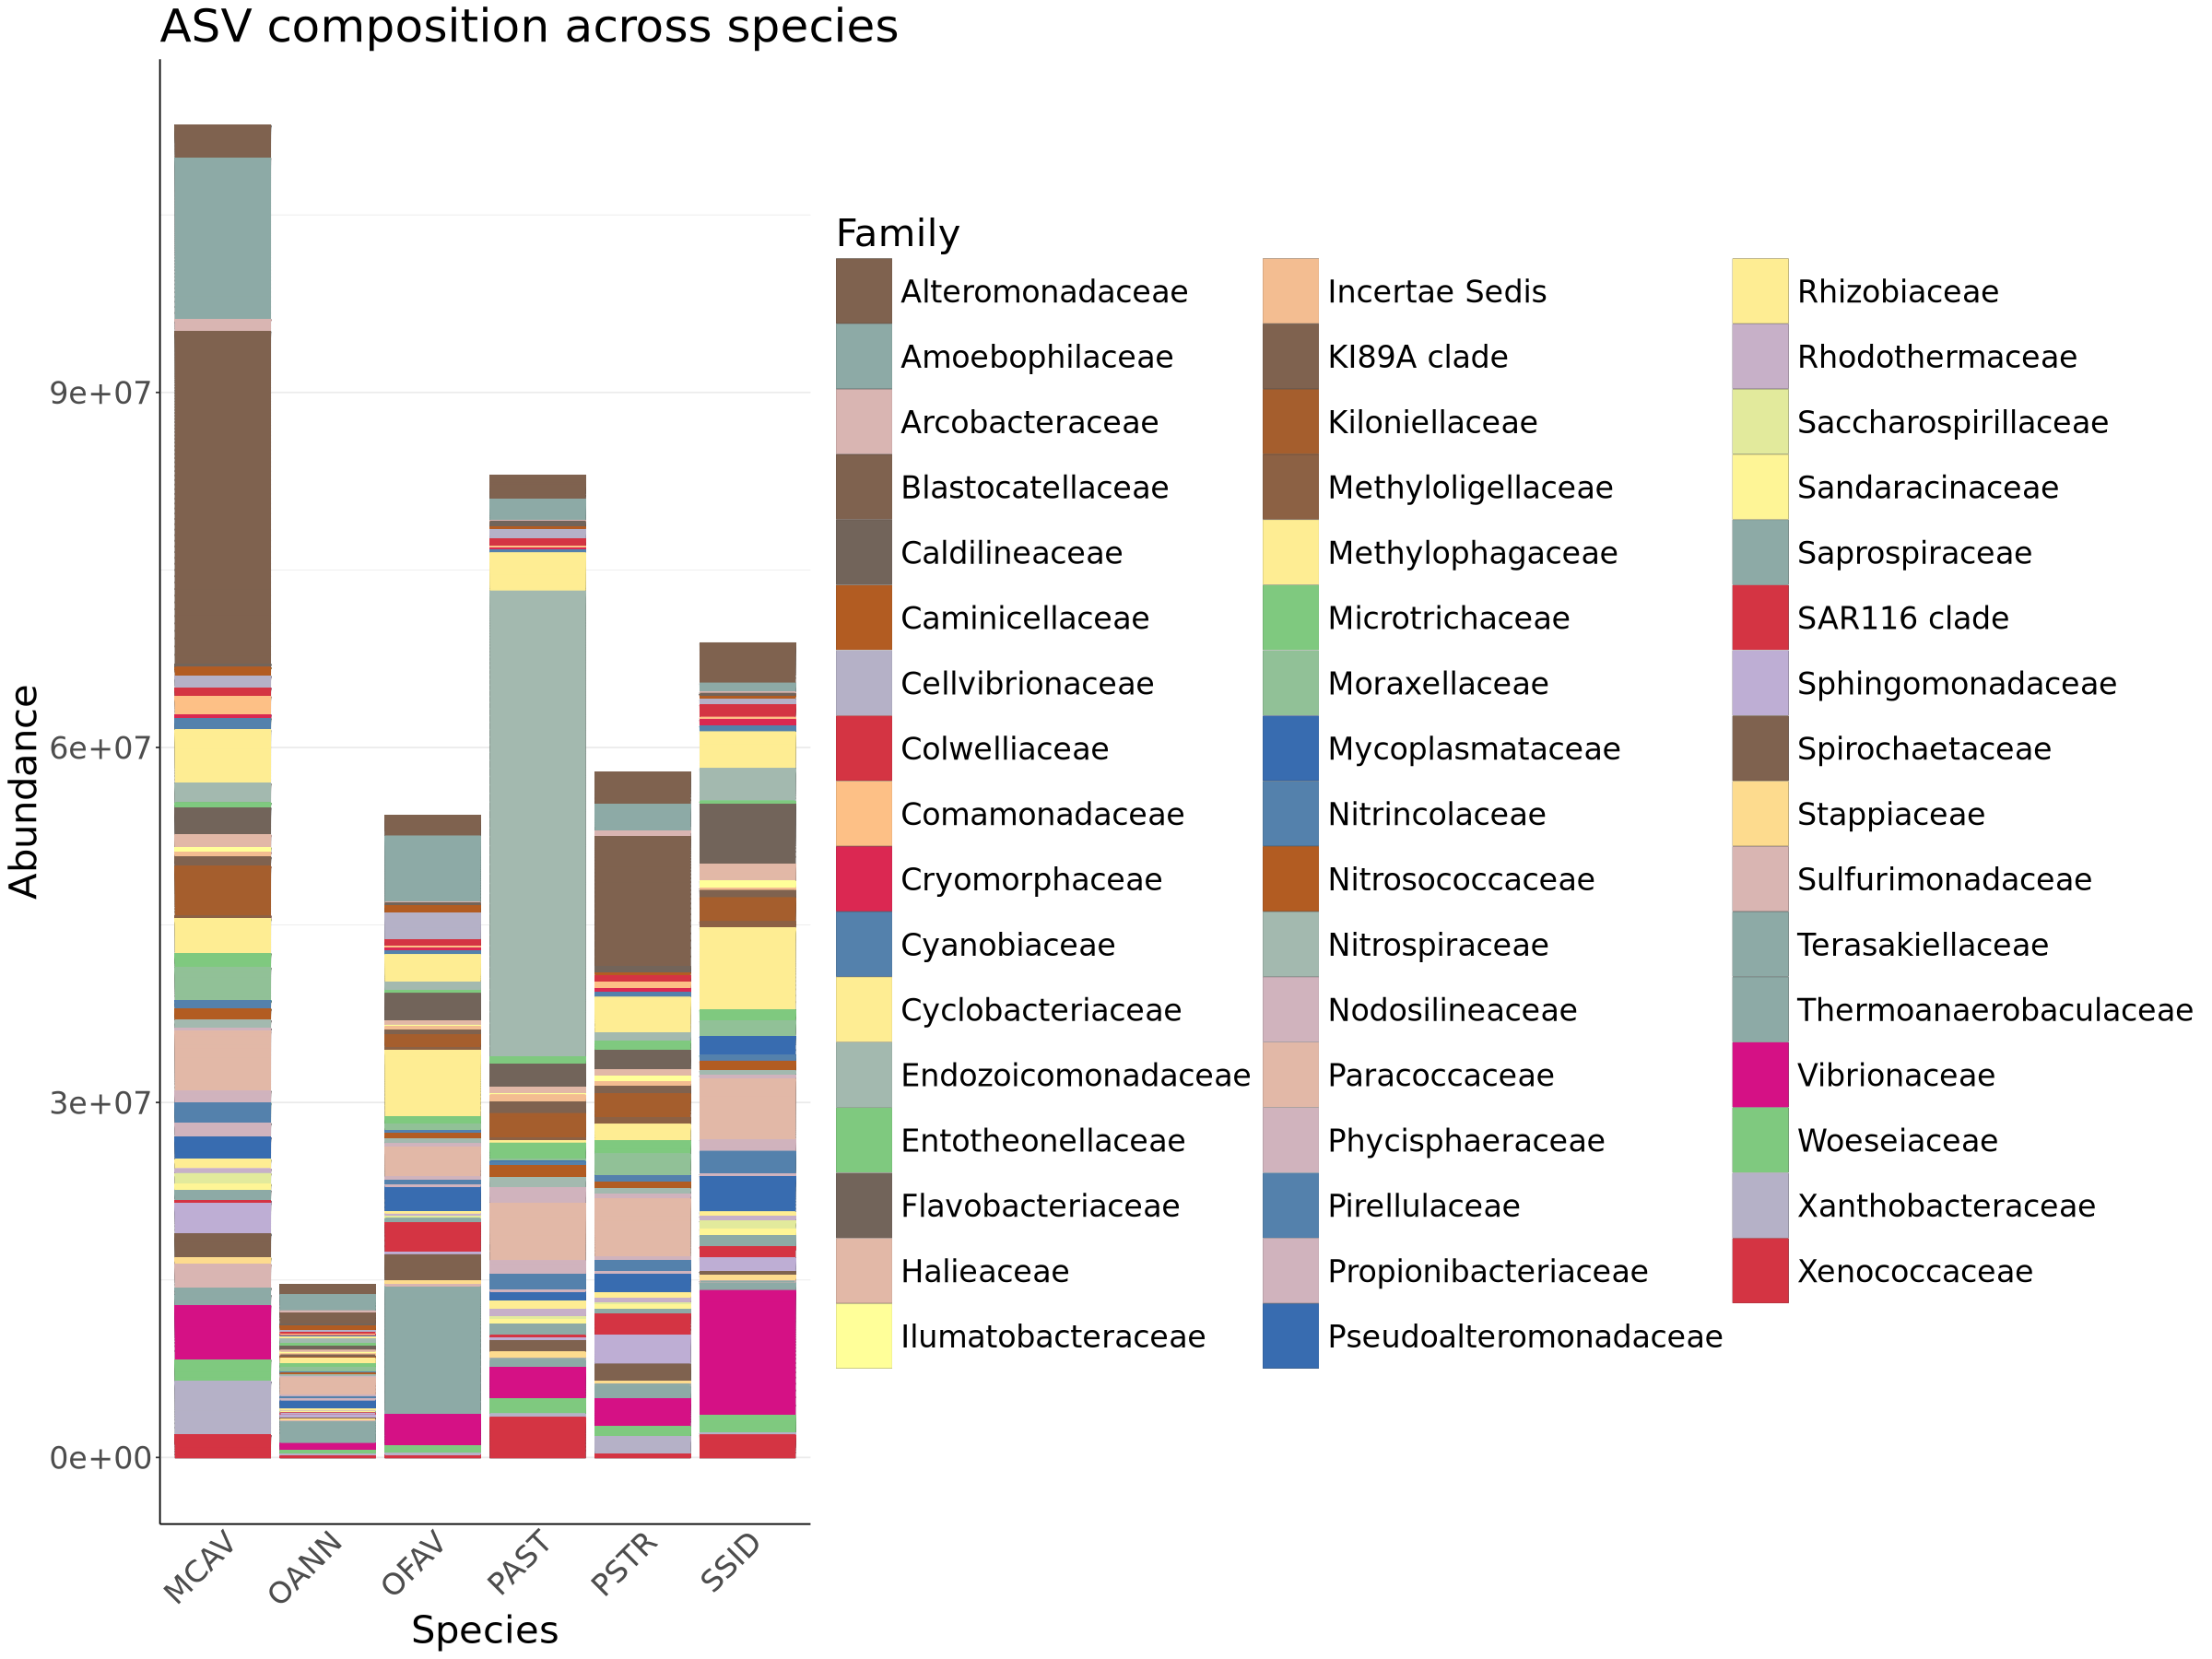

In [58]:
fam <- plot_bar(ps_fam_50, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Family") +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam

### top 50 taxa in more than 5% of samples

In [59]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm_5)[, "Family"]))

#reduce that to top 50
ps_fam_5=tax_glom(ps_norm_5, taxrank= "Family")

#isolating top 50 family taxa
top50_5<- names(sort(taxa_sums(ps_fam_5), decreasing=TRUE))[1:50] 
ps_fam_50_5 <- prune_taxa(top50_5, ps_fam_5) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam_50_5)[, "Family"]))

[1] 236

[1] 50

<Guides[1] ggproto object>

colour : <GuideLegend>

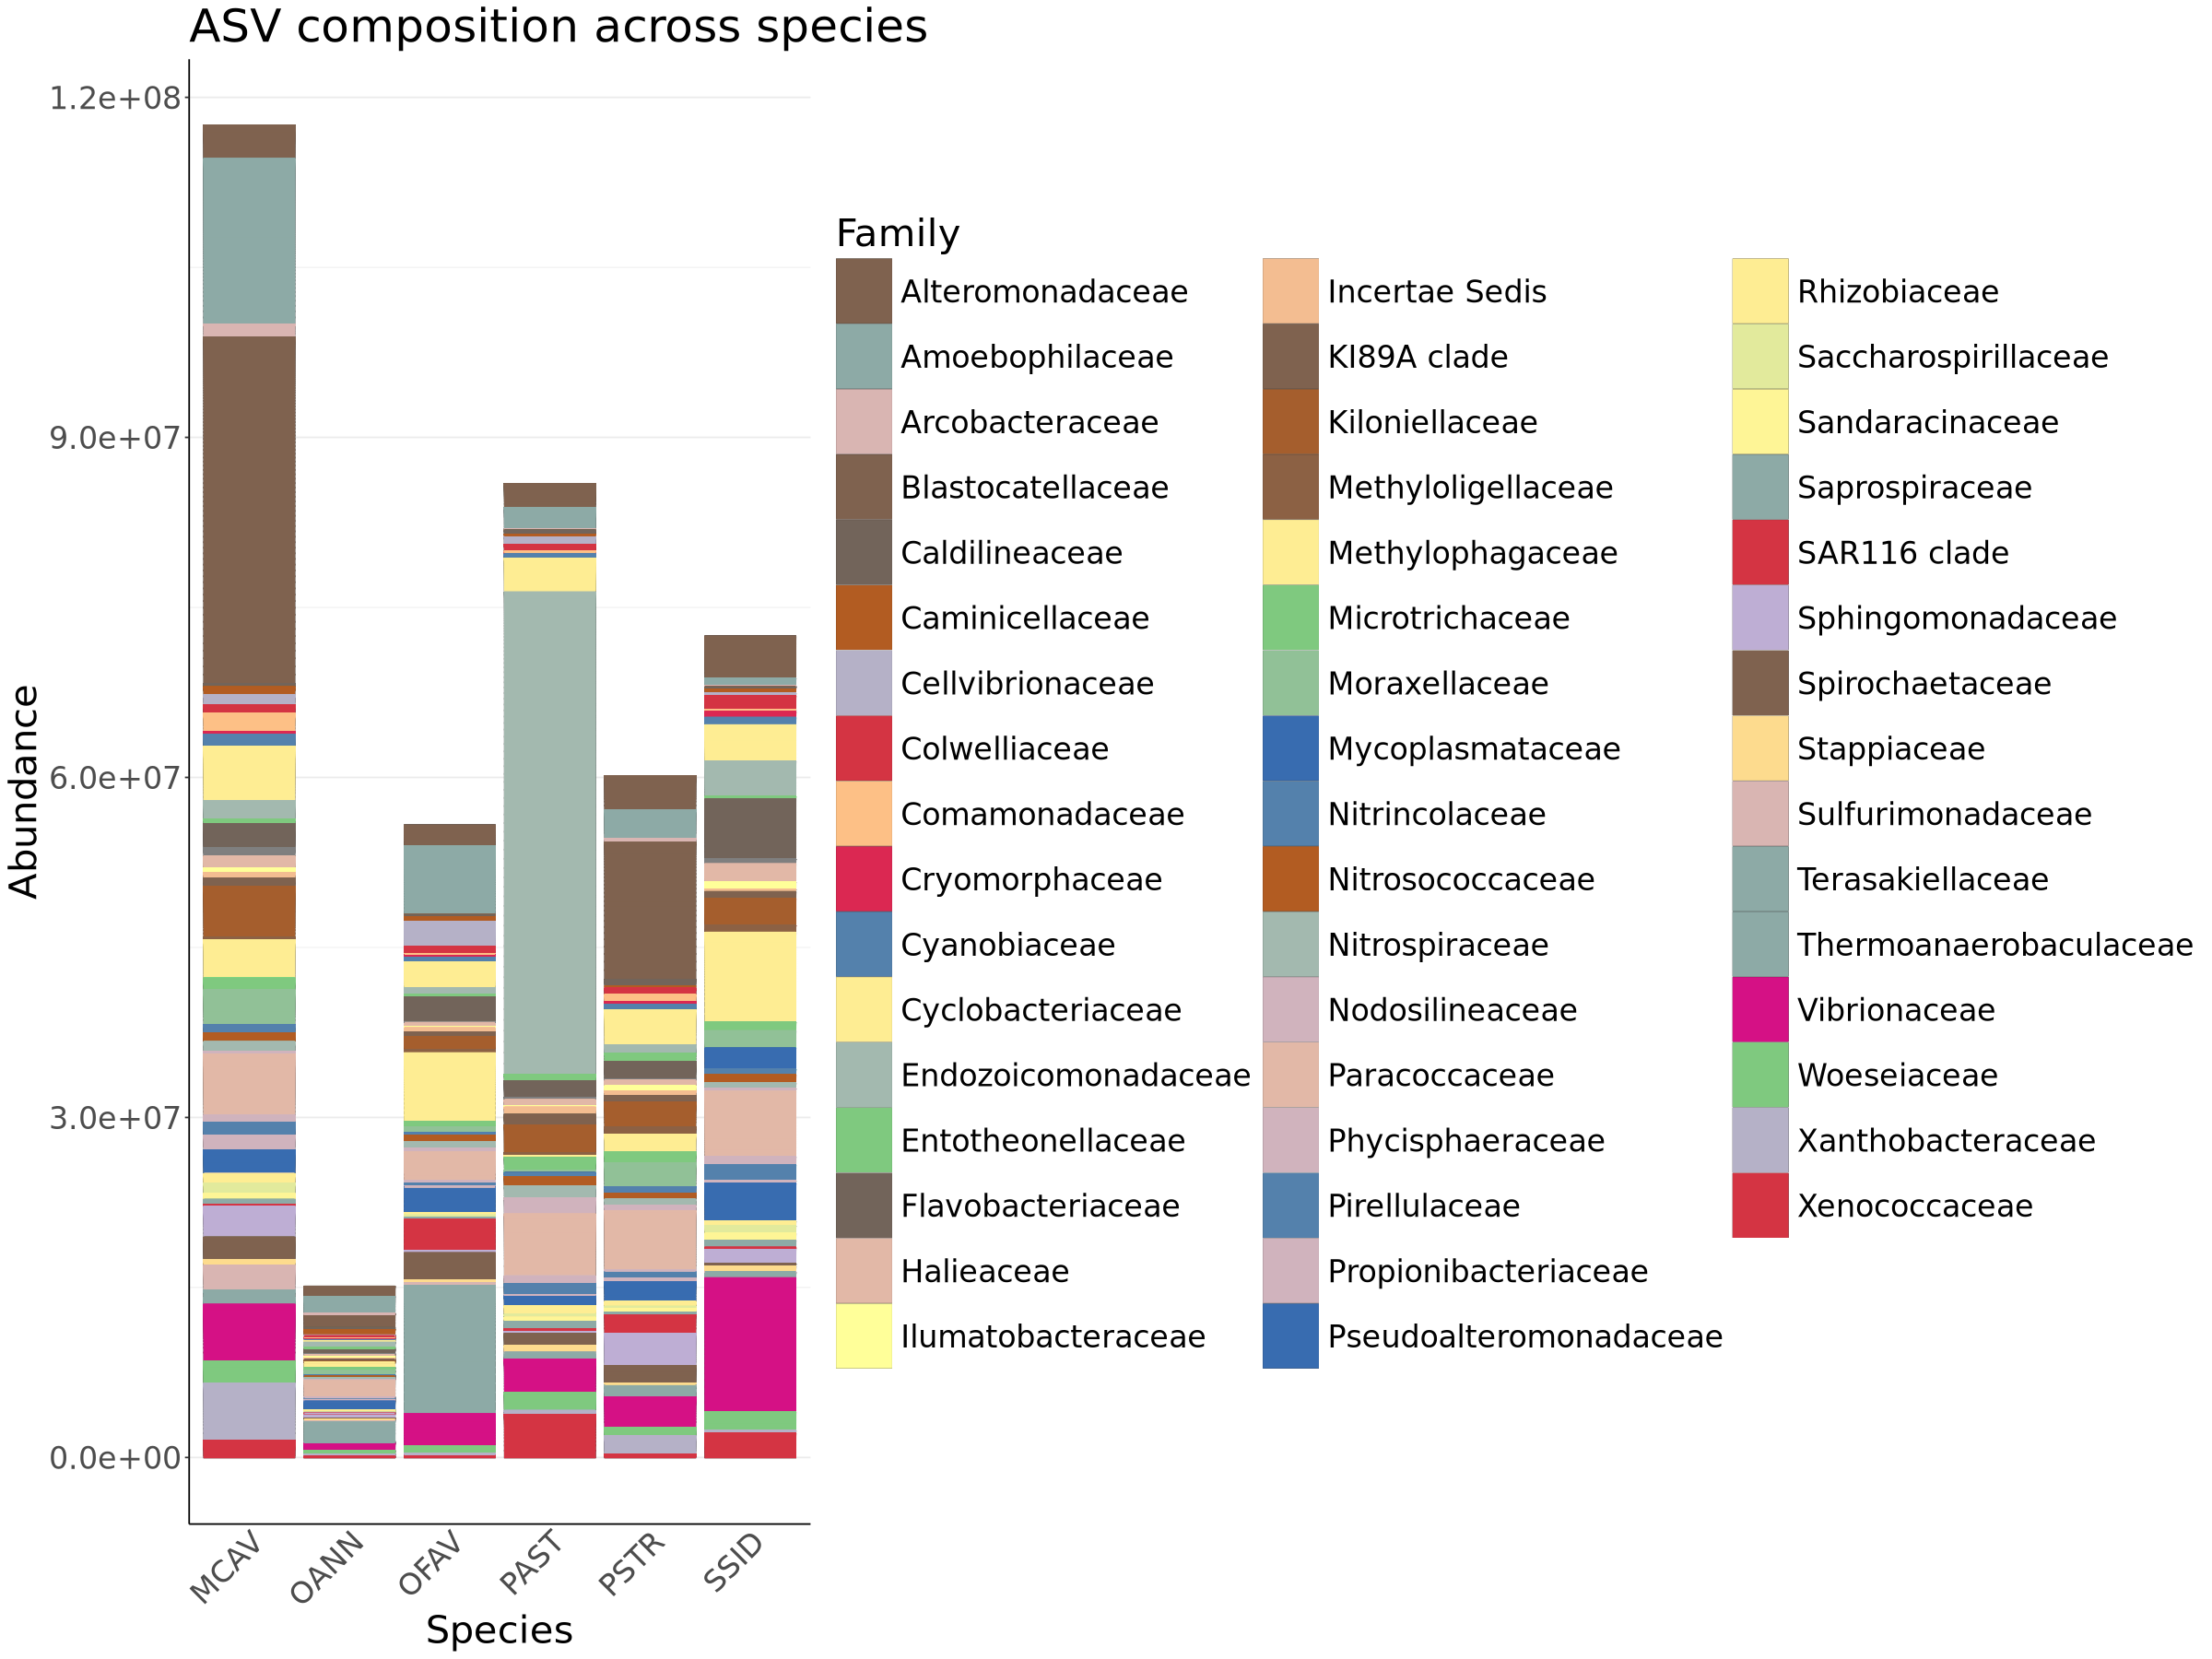

In [60]:
fam_5 <- plot_bar(ps_fam_50_5, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Family") +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_5

## all Order instead of top family taxa

In [61]:
    # how many unique order taxa are there?
length(unique(tax_table(ps_norm)[, "Order"]))
length(unique(tax_table(ps_norm_5)[, "Order"]))

[1] 210

[1] 117

In [62]:
#assigning colors
ordcolors_all= colorRampPalette(brewer.pal(8, "Accent"))(210)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
ord_taxa_all <- unique(tax_table(ps_norm)[, "Order"])
    ordcolors_all <- sample(ordcolors_all, 210, length(ord_taxa_all))
    # naming my color palette so the random order stays the same
    ordcolors_all<- setNames(ordcolors_all, ord_taxa_all)

In [ ]:
ord_all <- plot_bar(ps_norm, x="Species", fill = "Order") +
  geom_bar(aes(color = Order, fill = Order), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Order") +
  scale_fill_manual(values = ordcolors_all, drop = TRUE) +
  scale_color_manual(values = ordcolors_all, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    # Shrink the legend text and titles
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 8),
    
    # Shrink the physical size of the color boxes
    legend.key.width = unit(0.4, "cm"),     
    legend.key.height = unit(0.4, "cm"),   
    
    # Reduce spacing between legend items to compress it vertically
    legend.spacing.y = unit(0.1, "cm"),
    legend.box.spacing = unit(0.2, "cm"),
    
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  ) +
  # Shrink the override aesthetic size for the dots/lines in the legend
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) 

ord_all

In [ ]:
ord_5 <- plot_bar(ps_norm_5, x="Species", fill = "Order") +
  geom_bar(aes(color = Order, fill = Order), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Order") +
  scale_fill_manual(values = ordcolors_all, drop = TRUE) +
  scale_color_manual(values = ordcolors_all, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    # Shrink the legend text and titles
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 8),
    
    # Shrink the physical size of the color boxes
    legend.key.width = unit(0.4, "cm"),     
    legend.key.height = unit(0.4, "cm"),   
    
    # Reduce spacing between legend items to compress it vertically
    legend.spacing.y = unit(0.1, "cm"),
    legend.box.spacing = unit(0.2, "cm"),
    
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  ) +
  # Shrink the override aesthetic size for the dots/lines in the legend
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) 

# Display the plot
ord_5

In [ ]:
#isolating top 300 family taxa
top300<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:300] 
ps_fam_300 <- prune_taxa(top300, ps_fam) 